# 🕵️‍♂️ Aula Prática: Detecção de Fraudes em Cartões de Crédito (Com Visualizações)

Bem-vindos alunos! Nesta aula, além de criar uma Inteligência Artificial capaz de identificar transações fraudulentas, vamos **visualizar** essas informações através de gráficos e dashboards interativos.

**O que vamos fazer:**
1. Importar as ferramentas e bibliotecas gráficas.
2. Carregar e entender o desbalanceamento dos dados com gráficos.
3. Separar base, Nivelar dados e Treinar o Modelo.
4. Testar a I.A.
5. **📊 Módulo Visual:** Gerar gráficos explicativos das métricas e acertos do nosso robô!

## 📦 Passo 1: Importando as Ferramentas (Bibliotecas)

Vamos adicionar duas novas bibliotecas fundamentais para visualização no Python:
- **matplotlib**: O alicerce da criação de gráficos matemáticos no Python.
- **seaborn**: Uma biblioteca focada em gráficos estatísticos maravilhosos (com cores e temas bem acabados).

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import StandardScaler
import os

# Configurando o estilo visual dos gráficos do Seaborn
sns.set_theme(style="whitegrid", palette="pastel")

print("✅ Bibliotecas importadas com sucesso! Nossa caixa de ferramentas está pronta com recursos visuais.")

✅ Bibliotecas importadas com sucesso! Nossa caixa de ferramentas está pronta com recursos visuais.


## 📂 Passo 2: Carregando a Base de Dados

O arquivo `creditcard.csv` tem as features "mascaradas" (V1 ao V28) por motivos de segurança, e a coluna alvo `Class`.
- `0` indica transação **Normal**.
- `1` indica **Fraude**.

In [3]:
# Nome do nosso arquivo que está na mesma pasta
file_path = 'creditcard.csv'

# O pandas vai ler o arquivo CSV e carregar numa variável 'df'
if not os.path.exists(file_path):
    print(f"⚠️ ATENÇÃO: Arquivo {file_path} não encontrado na pasta atual.")
else:
    df = pd.read_csv(file_path)
    print(f"✅ Base carregada! Temos {len(df)} transações.")
    display(df.head())

✅ Base carregada! Temos 284807 transações.


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## ⚖️ Passo 3 e Gráfico 1: O Desbalanceamento Vizualizado

Antes, vimos que é procurar uma agulha no palheiro. Vamos plotar um gráfico de contagem para entender isso de forma visual. É um gráfico clássico de barras.

C:\Users\neublis\AppData\Local\Temp\ipykernel_6680\1530176083.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Class', data=df, palette=['#1f77b4', '#d62728'])


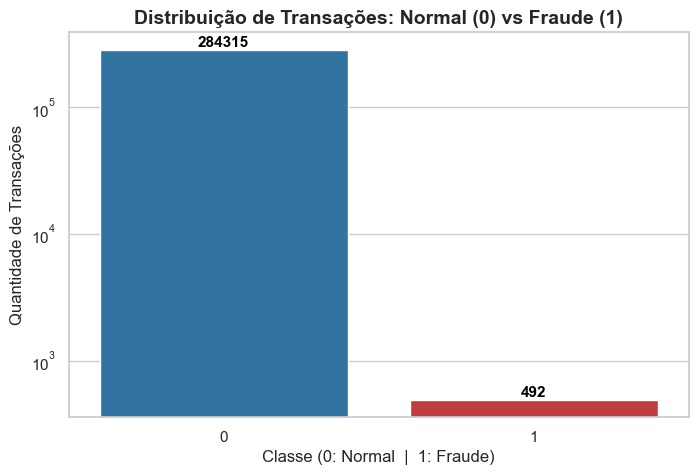

💡 Detalhe para a Escala Logarítmica no eixo Y (Sobe multiplicando por 10). A diferença visível seria nula em uma escala padrão de milhões!


In [4]:
if 'df' in locals():
    # Vamos contar
    contagem = df['Class'].value_counts()
    
    plt.figure(figsize=(8, 5))
    ax = sns.countplot(x='Class', data=df, palette=['#1f77b4', '#d62728'])
    
    plt.title('Distribuição de Transações: Normal (0) vs Fraude (1)', fontsize=14, fontweight='bold')
    plt.xlabel('Classe (0: Normal  |  1: Fraude)', fontsize=12)
    plt.ylabel('Quantidade de Transações', fontsize=12)
    
    # Colocar o número exato em cima das barras para o aluno notar o peso
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', fontsize=11, fontweight='bold', color='black')

    # Altera a escala do eixo Y para Logarítmica, pois a diferença é brutal!
    plt.yscale('log')
    plt.show()
    
    print("💡 Detalhe para a Escala Logarítmica no eixo Y (Sobe multiplicando por 10). A diferença visível seria nula em uma escala padrão de milhões!")

## ✂️ Passos 4, 5 e 6: Preparação Rápida dos Dados

Agora vamos concentrar as etapas de separação de `X` e `y`, a quebra do treino e teste, e o nivelamento, de forma agilizada na mesma célula.

In [5]:
if 'df' in locals():
    X = df.drop(columns=['Class'])
    y = df['Class']

    # Separando 80/20% com proporção (stratify)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    print(f"📚 Quantidade para Treino: {len(X_train)}")
    print(f"📝 Quantidade para Teste: {len(X_test)}")

    # Nivelamento (Scala Standard)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    print("✅ Dados escalonados com estatística normal.")

📚 Quantidade para Treino: 227845
📝 Quantidade para Teste: 56962
✅ Dados escalonados com estatística normal.


## 🧠 Passo 7: Treino e Teste (Regressão Logística)

Com o parâmetro de balanceamento de classes ativado, nossa I.A. foca mais nos erros da classe minoritária.

In [6]:
if 'df' in locals():
    # Modelo equilibrado lidará muito bem com assimetria
    modelo = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
    
    # ⏳ Treino...
    print("Treinando o modelo...")
    modelo.fit(X_train_scaled, y_train)

    # 📝 Validação...
    previsoes = modelo.predict(X_test_scaled)
    # Probabilidades numéricas de ser Fraude ou não (Será usado nos gráficos)
    probabilidades = modelo.predict_proba(X_test_scaled)[:, 1] 

    print("✅ Previsões prontas para nossa análise de resultados visuais!")

Treinando o modelo...
✅ Previsões prontas para nossa análise de resultados visuais!


## 📊 Gráfico 2: Heatmap da Matriz de Confusão Mestra

Lembra daquela matriz quadrada esmagada do passo anterior? Vamos colori-la com um mapa de calor, onde valores altos recebem tons mais fortes. A leitura será imediata comparado à matriz de texto bruto!

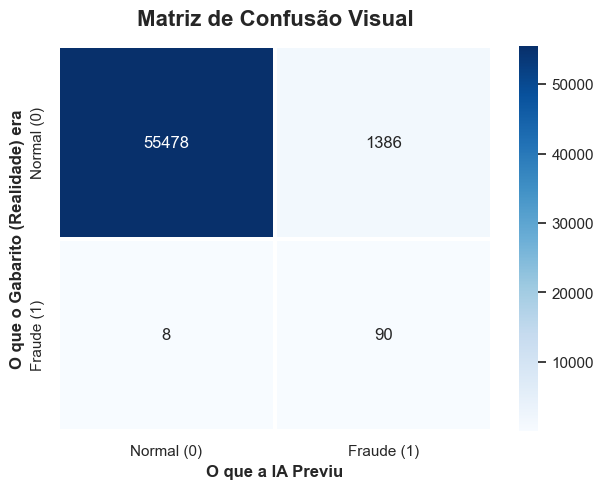

💡 Como ler: Cores mais escuras = mais registros.
-> Diagonal Principal (Canto esquerdo alto e Canto direito baixo) são os ACERTOS.
-> Diagonal Secundária são os ERROS (Falso-Positivo e Falso-Negativo).


In [7]:
if 'df' in locals():
    matriz = confusion_matrix(y_test, previsoes)
    
    plt.figure(figsize=(7, 5))
    sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', linewidths=1.5,
                xticklabels=['Normal (0)', 'Fraude (1)'],
                yticklabels=['Normal (0)', 'Fraude (1)'])

    plt.title('Matriz de Confusão Visual', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('O que a IA Previu', fontsize=12, fontweight='bold')
    plt.ylabel('O que o Gabarito (Realidade) era', fontsize=12, fontweight='bold')
    
    plt.show()
    
    print("💡 Como ler: Cores mais escuras = mais registros.")
    print("-> Diagonal Principal (Canto esquerdo alto e Canto direito baixo) são os ACERTOS.")
    print("-> Diagonal Secundária são os ERROS (Falso-Positivo e Falso-Negativo).")

## 📈 Gráfico 3: Curva ROC e AUC (A Força da Detecção)

A **Curva ROC** é o gráfico mais famoso da Ciência de Dados para medir a força de previsões binárias.
Ele plota como a IA se comporta em todas as sensibilidades quando tentamos balancear os "Verdadeiros Positivos" (Acertos de Crime) vs "Falsos Positivos" (Bloqueios Injustos).
A métrica **AUC** (Área sob a curva) mede do 0 ao 1. Quando mais próximo do 1.0 ou do teto esquerdo do gráfico, mais o seu algoritmo é gênio.

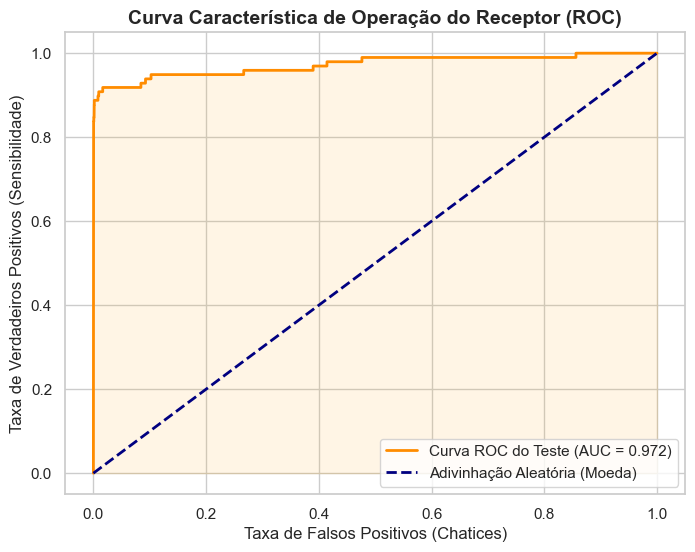

In [8]:
if 'df' in locals():
    fpr, tpr, thresholds = roc_curve(y_test, probabilidades)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC do Teste (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Adivinhação Aleatória (Moeda)')
    
    plt.fill_between(fpr, tpr, color='orange', alpha=0.1)
    
    plt.title('Curva Característica de Operação do Receptor (ROC)', fontsize=14, fontweight='bold')
    plt.xlabel('Taxa de Falsos Positivos (Chatices)')
    plt.ylabel('Taxa de Verdadeiros Positivos (Sensibilidade)')
    plt.legend(loc="lower right")
    
    plt.show()

## 🎯 Gráfico 4: Curva Precision-Recall (Sensibilidade x Precisão)

Enquanto a ROC é boa, ela pode enganar quando os dados são absurdamente desbalanceados. A curva **Precision-Recall** foca exclusivamente no que mais nos machuca: Como fica minha *Precisão de Alarme* se eu exigir *100% de Sensibilidade ao Crimininalo*?

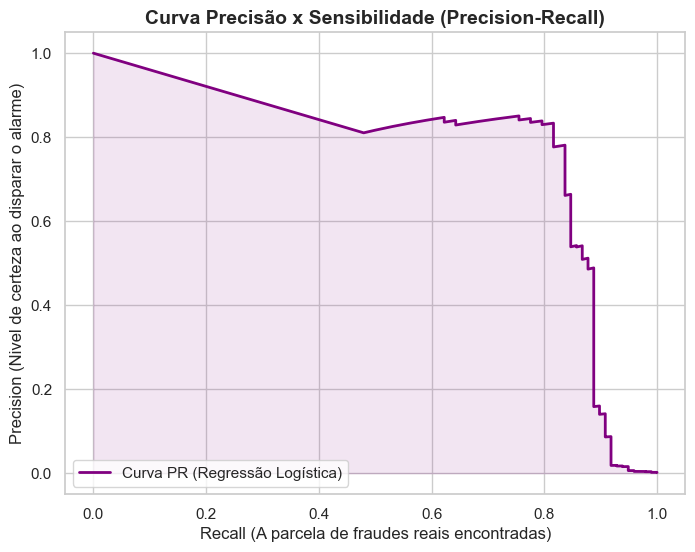

💡 A balança impossível: Observamos quanto a Precisão do Banco despenca, quanto mais gulosos somos para atingir 100% de bloqueios de fraude (Recall próximo do 1).


In [9]:
if 'df' in locals():
    precision, recall, _ = precision_recall_curve(y_test, probabilidades)

    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, color='purple', lw=2, label='Curva PR (Regressão Logística)')
    
    plt.title('Curva Precisão x Sensibilidade (Precision-Recall)', fontsize=14, fontweight='bold')
    plt.xlabel('Recall (A parcela de fraudes reais encontradas)', fontsize=12)
    plt.ylabel('Precision (Nivel de certeza ao disparar o alarme)', fontsize=12)
    plt.fill_between(recall, precision, color='purple', alpha=0.1)
    plt.legend(loc="lower left")
    
    plt.show()
    
    print("💡 A balança impossível: Observamos quanto a Precisão do Banco despenca, quanto mais gulosos somos para atingir 100% de bloqueios de fraude (Recall próximo do 1).")

## 📊 Gráfico 5: Distribuição Histográfica das Probabilidades da I.A.

O modelo não cospe um "0" ou um "1" absoluto. Internamente, ele calcula um valor matemático de 0.00% a 100.00% de chance daquela pessoa ser um golpista (Threshold). Se a chance passar de 50%, ele aciona "1". 

Nesse gráfico de densidades incríveis sobrepostas, vemos em azul os clientes Honestos e em Laranja os Criminosis baseados na pontuação final dada pela Regressão.

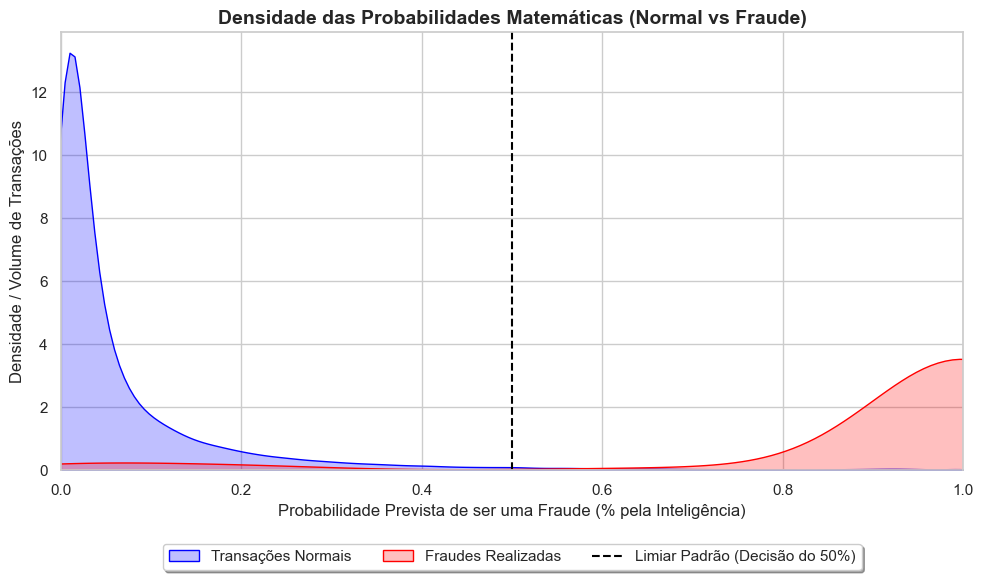

💡 Se o gráfico laranja e o azul estivessem perfeitamente separados sem se encostar, teríamos inventado um detetive divino e perfeito com 100% de eficácia.
As áreas que se misturam no limiar dos 50% são exatamente nossas angústias da Matriz de Confusão (Os Erros por hesitação).


In [10]:
if 'df' in locals():
    plt.figure(figsize=(10, 6))
    
    # Probabilidades separadas para base normal X base fraude
    probs_normal = probabilidades[y_test == 0]
    probs_fraude = probabilidades[y_test == 1]

    # KDE = Density Plot (Curvas densamente alisadas de Histograma)
    sns.kdeplot(probs_normal, color="blue", fill=True, label='Transações Normais')
    sns.kdeplot(probs_fraude, color="red", fill=True, label='Fraudes Realizadas')
    
    # Adicionando uma linha vertical cortando os 50% matemáticos
    plt.axvline(0.5, color='black', linestyle='--', label='Limiar Padrão (Decisão do 50%)')

    plt.xlim(0, 1)
    plt.title('Densidade das Probabilidades Matemáticas (Normal vs Fraude)', fontsize=14, fontweight='bold')
    plt.xlabel('Probabilidade Prevista de ser uma Fraude (% pela Inteligência)', fontsize=12)
    plt.ylabel('Densidade / Volume de Transações', fontsize=12)
    plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), fancybox=True, shadow=True, ncol=3)

    plt.tight_layout()
    plt.show()

    print("💡 Se o gráfico laranja e o azul estivessem perfeitamente separados sem se encostar, teríamos inventado um detetive divino e perfeito com 100% de eficácia.")
    print("As áreas que se misturam no limiar dos 50% são exatamente nossas angústias da Matriz de Confusão (Os Erros por hesitação).")

## 🏁 Conclusão Final (O Boletim)
Os gráficos são recursos muito valiosos para apresentar resultados técnicos a diretores sem jargões indecifráveis, traduzindo complexidade em calor de barras!

In [11]:
if 'df' in locals():
    print("==== 📝 BOLETIM FINAL DO MODELO ====\n")
    print(classification_report(y_test, previsoes))
    print(f"\n🏆 Acurácia de Acertos Gerais na População de Teste: {accuracy_score(y_test, previsoes) * 100:.2f}%")
    print("\nParabéns! Fim da Prática e Boas Demonstrações para vocês!")

==== 📝 BOLETIM FINAL DO MODELO ====

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962


🏆 Acurácia de Acertos Gerais na População de Teste: 97.55%

Parabéns! Fim da Prática e Boas Demonstrações para vocês!
